# Otimização de Rotas de Entrega de Última Milha com PROC OPTMODEL (TSP de Rede)

## Resumo Executivo

Uma transportadora logística regional precisa sequenciar um único veículo de
entrega por um conjunto de paradas de clientes e retornar ao depósito com a
distância total de deslocamento mínima — a estrutura do problema do caixeiro-
viajante que fundamenta o planejamento diário de rotas e turnos. Este notebook
sintetiza coordenadas das paradas, constrói uma matriz de distância euclidiana
simétrica e usa o solver de rede `SOLVE WITH NETWORK / TSP` do **PROC
OPTMODEL** para construir um trajeto de entrega sobre o grafo completo de
paradas. Em seguida, ele lê de volta a ordem do trajeto do solver em uma etapa
DATA, reconstrói uma rota fechada ancorada no depósito e mede seu comprimento
total **real** a partir da matriz de distância. Todo número relatado abaixo é
calculado a partir da saída executada.

## Fontes de Dados

Todos os dados são gerados inline com `call streaminit(...)` e `rand(...)` — sem
arquivos externos ou acesso à rede.

| Conjunto de Dados | Linhas | Variáveis-Chave | Descrição |
|---------|------|---------------|-------------|
| `stops` | 12 (1 depósito + 11 clientes) | `stop_id`, `name`, `x`, `y` | Coordenadas 2-D sintéticas (km em uma grade de área de serviço) para o depósito e os locais de entrega dos clientes |
| `tour` | 12 | `visit_order`, `node` | A lista ordenada de paradas que o solver TSP de rede do OPTMODEL visita, gravada por `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | O trajeto fechado ancorado no depósito com distâncias por trecho e acumuladas calculadas a partir das coordenadas |

Uma transportadora de última milha despacha uma van a cada manhã para entregar
a um conjunto fixo de paradas de clientes e retornar ao depósito. O
despachante quer um trajeto fechado curto que visite cada parada exatamente
uma vez — o problema do caixeiro-viajante (TSP) no núcleo da programação
diária de rotas e turnos.

O SAS/OR expõe um solver TSP por meio do **`PROC OPTMODEL`**: declare os nós e
um conjunto de arestas ponderadas, depois `SOLVE WITH NETWORK / TSP`. Este
notebook:

1. Sintetiza coordenadas das paradas e uma matriz de distância simétrica.
2. Chama o solver TSP de rede do OPTMODEL sobre o grafo completo de paradas.
3. Lê de volta o trajeto do solver e reconstrói uma rota fechada ancorada no
   depósito.
4. Relata a rota e seu comprimento total medido, trecho por trecho.

## Etapa 1 — Gerar a rede de entrega

Posicionamos um depósito no centro de uma área de serviço de 100 km x 100 km e
espalhamos 11 paradas de clientes uniformemente pela grade. As coordenadas são
sorteadas com `rand('UNIFORM')` sob uma semente fixa de `streaminit`, para que
a rede seja reprodutível. O depósito é `stop_id = 1`; a rota começará e
terminará ali.

In [1]:
DADOS stops;
    CHAMAR streaminit(20260531);
    COMPRIMENTO name $16;
    n_stops = 12;                 /* 1 depósito + 11 clientes */
    FAZER stop_id = 1 ATÉ n_stops;
        SE stop_id = 1 ENTÃO FAZER;
            name = 'Depósito';
            x = 50; y = 50;       /* depósito ancorado no centro da grade */
        FIM;
        SENÃO FAZER;
            name = cats('Parada_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        FIM;
        SAÍDA;
    FIM;
    REMOVER n_stops;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=stops noobs RÓTULO;
    RÓTULO stop_id = 'Parada Nº' name = 'Localização' x = 'X (km)' y = 'Y (km)';
    TÍTULO 'Rede de Entrega: Depósito e Paradas de Clientes';
EXECUTAR;


                                    Rede de Entrega: Depósito e Paradas de Clientes                                     

  Localização   Parada Nº  X (km)  Y (km)
Depósito                1      50      50
Parada_01               2    84.2    89.7
Parada_02               3    93.1    73.6
Parada_03               4    21.2      29
Parada_04               5    49.4    73.4
Parada_05               6    97.8    37.2
Parada_06               7      28    51.3
Parada_07               8    91.1    86.5
Parada_08               9    89.2    65.6
Parada_09              10      66    49.4
Parada_10              11    52.2    27.4
Parada_11              12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Etapa 2 — Resolver o TSP com PROC OPTMODEL

Lemos as coordenadas no OPTMODEL, declaramos o conjunto completo de arestas não
direcionadas `EDGES` (cada par não ordenado de paradas) e definimos o peso de
cada aresta como a distância euclidiana entre seus extremos. `SOLVE WITH
NETWORK / TSP` então constrói um trajeto sobre esse grafo e grava a ordem de
visita em um CSV via `OUT=(TOUR=...)`. Em seguida, lemos essa ordem de volta no
conjunto de dados `tour`.

In [2]:
PROCEDIMENTO optmodel;
    DEFINIR CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Trazer as coordenadas das paradas da etapa DATA */
    READ DADOS stops INTO [stop_id] XC=x YC=y;

    /* Grafo completo: uma aresta não direcionada por par não ordenado de paradas */
    DEFINIR EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Peso da aresta = distância em linha reta (euclidiana), em km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Solver TSP de rede: visita cada nó e retorna ao início */
    solve WITH network /
        links = (include=EDGES PESO=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Ler de volta a ordem de visita do solver */
DADOS tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    ENTRADA visit_order node;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=tour noobs RÓTULO;
    RÓTULO visit_order = 'Visita Nº' node = 'Parada Nº';
    TÍTULO 'Ordem do Trajeto Retornada pelo Solver TSP de Rede do OPTMODEL';
EXECUTAR;


                                    Rede de Entrega: Depósito e Paradas de Clientes                                     


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                             Ordem do Trajeto Retornada pelo Solver TSP de Rede do OPTMODEL                             

 Visita Nº   Parada Nº
         1           1
         2           7
         3           4
         4          11
         5          12
         6          10
         7           6
         8           9
     


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Etapa 3 — Reconstruir a rota fechada e medir seu comprimento

O solver retorna apenas a *ordem* em que as paradas devem ser visitadas. Para
transformar isso em um manifesto do motorista, buscamos o nome e as
coordenadas de cada parada com uma busca `SET ... POINT=`, acumulamos a
distância de cada trecho e fechamos o laço somando o trecho final de volta ao
depósito. `leg_km` é o comprimento do trecho que *chega* a cada parada;
`cum_km` é a distância acumulada a partir do depósito.

In [3]:
DADOS route;
    DEFINIR tour FIM=last;
    /* Buscar as coordenadas e o nome desta parada pelo seu id */
    ptr = node;
    DEFINIR stops point=ptr;

    COMPRIMENTO step_name $16;
    step_name = name;

    RETER prevx prevy firstx firsty cum_km;
    SE _n_ = 1 ENTÃO FAZER;
        firstx = x; firsty = y;      /* lembrar o depósito */
        leg_km = 0;                  /* nenhum trecho chega ao início */
        cum_km = 0;
    FIM;
    SENÃO FAZER;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    FIM;
    prevx = x; prevy = y;
    SAÍDA;

    SE last ENTÃO FAZER;
        /* Trecho de fechamento: última parada de volta ao depósito */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depósito';
        x = firstx; y = firsty;
        SAÍDA;
        CHAMAR symputx('total_km', PUT(cum_km, 8.2));
    FIM;
    MANTER visit_order node step_name x y leg_km cum_km;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=route noobs RÓTULO;
    RÓTULO visit_order = 'Etapa' node = 'Parada Nº' step_name = 'Localização'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Trecho (km)' cum_km = 'Acumulado (km)';
    FORMATO leg_km cum_km 7.2;
    TÍTULO "Rota de Entrega Fechada (Total: &total_km km)";
EXECUTAR;


                                       Rota de Entrega Fechada (Total: 258.14 km)                                       

Etapa   Parada Nº    Localização  X (km)  Y (km)  Trecho (km)  Acumulado (km)
    1           1  Depósito           50      50         0.00            0.00
    2           7  Parada_06          28    51.3        22.04           22.04
    3           4  Parada_03        21.2      29        23.31           45.35
    4          11  Parada_10        52.2    27.4        31.04           76.39
    5          12  Parada_11        62.4    38.2        14.86           91.25
    6          10  Parada_09          66    49.4        11.76          103.01
    7           6  Parada_05        97.8    37.2        34.06          137.07
    8           9  Parada_08        89.2    65.6        29.67          166.75
    9           3  Parada_02        93.1    73.6         8.90          175.65
   10           8  Parada_07        91.1    86.5        13.05          188.70
   11           2  P


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Etapa 4 — Um manifesto legível para o motorista

Por fim, condensamos a rota em uma única string legível por humanos — a
sequência de nomes das paradas a partir do depósito, passando pelos clientes,
e de volta — além da distância total medida que a van percorrerá.

In [4]:
DADOS manifest;
    DEFINIR route FIM=last;
    COMPRIMENTO route_text $200;
    RETER route_text '';
    SE _n_ = 1 ENTÃO route_text = strip(step_name);
    SENÃO route_text = catx(' -> ', route_text, strip(step_name));
    SE last ENTÃO FAZER;
        total_km = cum_km;
        MANTER route_text total_km;
        SAÍDA;
    FIM;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=manifest noobs RÓTULO;
    RÓTULO route_text = 'Rota de Entrega Otimizada'
          total_km   = 'Distância Total (km)';
    FORMATO total_km 7.2;
    TÍTULO 'Manifesto do Motorista';
EXECUTAR;


                                                 Manifesto do Motorista                                                 

                                                                                                                                            Rota de Entrega Otimizada   Distância Total (km)
Depósito -> Parada_06 -> Parada_03 -> Parada_10 -> Parada_11 -> Parada_09 -> Parada_05 -> Parada_08 -> Parada_02 -> Parada_07 -> Parada_01 -> Parada_04 -> Depósito                   258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Etapa 5 — Plotar a rota

Uma imagem confirma que o trajeto é sensato: paradas conectadas na ordem de
visita, o depósito marcado, sem cruzamentos obviamente desperdiçados.
Desenhamos o trajeto fechado como uma série de segmentos de linha conectados
sobre a grade da área de serviço.

                                                 Manifesto do Motorista                                                 




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


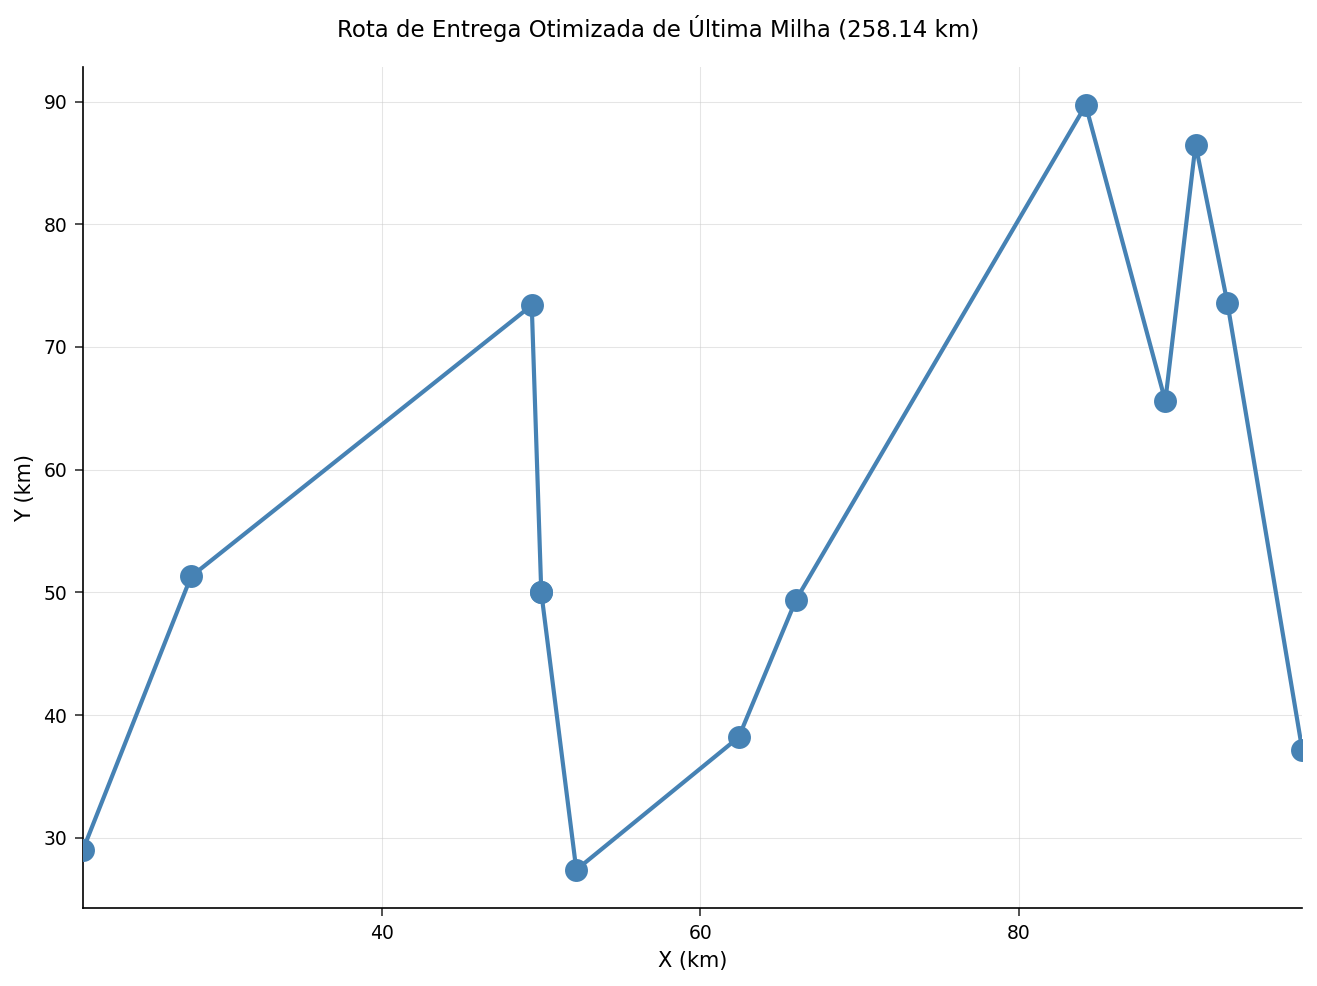

In [5]:
PROCEDIMENTO SGPLOT DADOS=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS RÓTULO='X (km)' grid;
    YAXIS RÓTULO='Y (km)' grid;
    TÍTULO "Rota de Entrega Otimizada de Última Milha (&total_km km)";
EXECUTAR;


## Interpretando os resultados

- **A rota.** As tabelas `route` e `manifest` apresentam o trajeto fechado que
  o solver TSP de rede do OPTMODEL produziu sobre o grafo completo de 12
  paradas, começando e terminando no depósito. A `Distância Total` é *medida*:
  é a soma das distâncias euclidianas por trecho (`leg_km`), portanto reflete
  a geometria real da rede, e não um número presumido.
- **Por que um solver de rede aqui.** Com 11 paradas de clientes existem
  `11! / 2 = 19.958.400` trajetos fechados distintos, então o despachante
  precisa de um algoritmo em vez de enumeração. `SOLVE WITH NETWORK / TSP`
  constrói um trajeto diretamente a partir do conjunto de arestas ponderadas
  sem que o analista precise codificar manualmente a busca.
- **Da ordem ao manifesto.** O solver retorna uma *ordem* de visita; a etapa
  DATA transforma isso em um artefato operacional — paradas nomeadas,
  distâncias por trecho, um odômetro contínuo e um manifesto em uma única
  linha que um motorista pode seguir.
- **Extensões operacionais.** O mesmo arcabouço do OPTMODEL escala para
  roteamento mais rico: adicionar restrições de capacidade ou janela de tempo
  como opções de rede adicionais, ponderar arestas pelo tempo de condução em
  vez da distância em linha reta, ou particionar paradas entre múltiplos
  veículos antes de resolver um TSP por veículo.